# CAPROT Analysis

Last edit date: 20260202  
Author: Jiawen Liang  
Project: CAPROT

### 0. 加载包

In [437]:
import os
import pandas as pd
import numpy as np
import pymysql
import logging
from datetime import date, datetime, timedelta
import traceback
import time
from typing import Union, List, Dict
import sys
import matplotlib.pyplot as plt

检查当前notebook的工作目录

In [438]:
print("当前工作目录:", os.getcwd())

当前工作目录: d:\jinfuziquant\src\caprot


### 1. 参数预设

In [439]:
# 数据文件路径
DATA_DIR = 'D:/jinfuziquant/data/caprot_data/merged_data_caprot.csv'

# 结果输出路径
OUTPUT_DIR = './results/caprot_output/'

# 回测时间
START_DATE = '2023-01-01'
END_DATE = '2099-12-31'

# 因子参数
STD_WINDOW = 126  # 核心周期：半年趋势 (需要调小一点)
RANK_WINDOW = 60  # 灵敏度：一季度自适应
SMOOTH_WINDOW = 5  # 平滑窗口

# 线性调仓阈值 逻辑：因子稍微偏离中枢，立即介入并锁定趋势
LINEAR_HIGH = 0.70  # Rank > 0.7 开始减仓
LINEAR_LOW = 0.30  # Rank < 0.3 开始加仓

# 标配区
NEUTRAL_L = 0.40
NEUTRAL_H = 0.60

# 单边棘轮
ENABLE_RATCHET = True

# 交易成本
COST = 0.0002
SLIPPAGE = 0.0003

# 全局绘图设置
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

### 1. 加载数据

In [440]:
def load_data(file_path: str) -> pd.DataFrame: # 指定返回值类型是DataFrame
    """
    加载数据文件，支持CSV和Excel格式
    :param file_path: 文件路径
    :return: 数据框
    """
    if file_path.endswith('.csv'):
        df = pd.read_csv(file_path)
        print(f"数据加载成功，文件类型为CSV，数据形状: {df.shape}")
    elif file_path.endswith('.xlsx') or file_path.endswith('.xls'):
        df = pd.read_excel(file_path)
        print(f"数据加载成功，文件类型为Excel，数据形状: {df.shape}")
    else:
        raise ValueError("加载失败，文件格式不支持")
    return df

df = load_data(DATA_DIR)

数据加载成功，文件类型为CSV，数据形状: (1237, 55)


### 3. 修改表头，简化名称

In [441]:
# 列名映射字典
rename_map = {
    'TradingDay': 'date',
    'idx_000905_SH__index_code': 'zz500_code',
    'idx_000905_SH__prev_close': 'zz500_prev_close',
    'idx_000905_SH__open_price': 'zz500_open',
    'idx_000905_SH__high_price': 'zz500_high',
    'idx_000905_SH__low_price': 'zz500_low',
    'idx_000905_SH__close_price': 'zz500_close',
    'idx_000905_SH__turnover_volume': 'zz500_vol',
    'idx_000905_SH__turnover_value': 'zz500_amt',
    'idx_000905_SH__change_pct': 'zz500_chg_pct',
    'idx_000905_SH__negotiable_mv': 'zz500_mv',
    'idx_000905_SH__index_return': 'zz500_ret',
    
    'idx_000300_SH__index_code': 'hs300_code',
    'idx_000300_SH__prev_close': 'hs300_prev_close',
    'idx_000300_SH__open_price': 'hs300_open',
    'idx_000300_SH__high_price': 'hs300_high',
    'idx_000300_SH__low_price': 'hs300_low',
    'idx_000300_SH__close_price': 'hs300_close',
    'idx_000300_SH__turnover_volume': 'hs300_vol',
    'idx_000300_SH__turnover_value': 'hs300_amt',
    'idx_000300_SH__change_pct': 'hs300_chg_pct',
    'idx_000300_SH__negotiable_mv': 'hs300_mv',
    'idx_000300_SH__index_return': 'hs300_ret',
    
    'fund_512510__fund_code': 'zz500etf_code',
    'fund_512510__prev_close': 'zz500etf_prev_close',
    'fund_512510__open_price': 'zz500etf_open',
    'fund_512510__high_price': 'zz500etf_high',
    'fund_512510__low_price': 'zz500etf_low',
    'fund_512510__close_price': 'zz500etf_close',
    'fund_512510__avg_price': 'zz500etf_avg',
    'fund_512510__change_of_price': 'zz500etf_chg',
    'fund_512510__change_pct': 'zz500etf_chg_pct',
    'fund_512510__turnover_rate': 'zz500etf_tovr',
    'fund_512510__turnover_volume': 'zz500etf_vol',
    'fund_512510__turnover_value': 'zz500etf_amt',
    'fund_512510__vibration_range': 'zz500etf_vib',
    'fund_512510__discount': 'zz500etf_disc',
    'fund_512510__discount_ratio': 'zz500etf_disc_rt',
    'fund_512510__fund_return': 'zz500etf_ret',
    
    'fund_510300__fund_code': 'hs300etf_code',
    'fund_510300__prev_close': 'hs300etf_prev_close',
    'fund_510300__open_price': 'hs300etf_open',
    'fund_510300__high_price': 'hs300etf_high',
    'fund_510300__low_price': 'hs300etf_low',
    'fund_510300__close_price': 'hs300etf_close',
    'fund_510300__avg_price': 'hs300etf_avg',
    'fund_510300__change_of_price': 'hs300etf_chg',
    'fund_510300__change_pct': 'hs300etf_chg_pct',
    'fund_510300__turnover_rate': 'hs300etf_tovr',
    'fund_510300__turnover_volume': 'hs300etf_vol',
    'fund_510300__turnover_value': 'hs300etf_amt',
    'fund_510300__vibration_range': 'hs300etf_vib',
    'fund_510300__discount': 'hs300etf_disc',
    'fund_510300__discount_ratio': 'hs300etf_disc_rt',
    'fund_510300__fund_return': 'hs300etf_ret'
}

# 修改列名函数
def rename_columns(df: pd.DataFrame, rename_map: Dict[str, str]) -> pd.DataFrame:
    """
    修改数据框的列名
    :param df: 输入数据框
    :param rename_map: 列名映射字典
    :return: 修改列名后的数据框
    """
    df = df.rename(columns=rename_map)
    return df

df = rename_columns(df, rename_map)
print("=============================== 数据预览 ===============================")
print(df.head())

=============================== 数据预览 ===============================
         date zz500_code  zz500_prev_close  zz500_open  zz500_high  zz500_low  \
0  2020/12/28  000905.SH         6278.4981   6283.7821   6288.2442  6219.0910   
1  2020/12/29  000905.SH         6244.4818   6240.7355   6280.0396  6196.4147   
2  2020/12/30  000905.SH         6199.8523   6196.4505   6289.2704  6188.5931   
3  2020/12/31  000905.SH         6269.2484   6282.9576   6370.5695  6281.0138   
4    2021/1/4  000905.SH         6367.1149   6395.6118   6501.5892  6359.0797   

   zz500_close    zz500_vol     zz500_amt  zz500_chg_pct  ...  hs300etf_avg  \
0    6244.4818  14896021400  1.600000e+11      -0.541790  ...        5.1257   
1    6199.8523  15447603200  1.560000e+11      -0.714703  ...        5.1242   
2    6269.2484  13804167300  1.480000e+11       1.119319  ...        5.1568   
3    6367.1149  16019408600  1.740000e+11       1.561056  ...        5.2579   
4    6482.7868  18662120900  2.110000e+11       1

### 4. 数据检查与清洗

In [442]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    数据清洗函数，处理缺失值和异常值
    :param df: 输入数据框
    :return: 清洗后的数据框
    """
    try:
        # 1. 将日期列转换为datetime格式
        df['date'] = pd.to_datetime(df['date'])
        print("日期格式转换成功")
        
        # 2. 按日期升序排列
        df = df.sort_values(by='date').reset_index(drop=True)
        df = df.set_index('date')
        print("数据排序成功，按日期升序排列")
        
        return df
    except Exception as e:
        raise ValueError(f"❌ 数据清洗失败: {e}")

df = clean_data(df)
# 预览清洗后的数据
print("=============================== 清洗后数据预览 ===============================")
print(df.head())

日期格式转换成功
数据排序成功，按日期升序排列
=============================== 清洗后数据预览 ===============================
           zz500_code  zz500_prev_close  zz500_open  zz500_high  zz500_low  \
date                                                                         
2020-12-28  000905.SH         6278.4981   6283.7821   6288.2442  6219.0910   
2020-12-29  000905.SH         6244.4818   6240.7355   6280.0396  6196.4147   
2020-12-30  000905.SH         6199.8523   6196.4505   6289.2704  6188.5931   
2020-12-31  000905.SH         6269.2484   6282.9576   6370.5695  6281.0138   
2021-01-04  000905.SH         6367.1149   6395.6118   6501.5892  6359.0797   

            zz500_close    zz500_vol     zz500_amt  zz500_chg_pct  \
date                                                                
2020-12-28    6244.4818  14896021400  1.600000e+11      -0.541790   
2020-12-29    6199.8523  15447603200  1.560000e+11      -0.714703   
2020-12-30    6269.2484  13804167300  1.480000e+11       1.119319   
2020-12-31  

### 5. 因子计算

In [443]:
def calculate_factor(df):

    print(f"正在计算因子 (Std={STD_WINDOW}, Rank={RANK_WINDOW})...")

    # 读取成交额数据
    tv_500 = df['zz500_amt'].replace(0, np.nan).ffill()
    tv_hl = df['hs300_amt'].replace(0, np.nan).ffill()

    # 取对数
    ln_tv_500 = np.log(tv_500)
    ln_tv_hl = np.log(tv_hl)

    # 计算滚动标准差
    std_500 = ln_tv_500.rolling(window=STD_WINDOW).std()
    std_hl = ln_tv_hl.rolling(window=STD_WINDOW).std()

    # 计算初始因子值
    factor_raw = std_500 - std_hl

    # 计算平滑因子值
    factor_smooth = factor_raw.rolling(SMOOTH_WINDOW).mean()

    # 预览平滑因子值
    print("=============================== 平滑因子预览 ===============================")
    print("factor_smooth 最后部分值:", factor_smooth.tail(50).values)

    # 归一化 Rank [0, 1]
    raw_rank = factor_smooth.rolling(RANK_WINDOW).rank(pct=False)
    # 预览 raw_rank
    print("raw_rank 最后部分值:", raw_rank.tail(50).values)

    factor_rank = (raw_rank - 1) / (RANK_WINDOW - 1)


    res = df.copy()
    res['Factor_Rank'] = factor_rank
    return res

df = calculate_factor(df)
print("=============================== 计算完成 ===============================")
# 查看新计算的因子列
# print(df[['date', 'Factor_Rank']].iloc[187:401])

正在计算因子 (Std=126, Rank=60)...
=============================== 平滑因子预览 ===============================
factor_smooth 最后部分值: [-0.00785792 -0.00744266 -0.00690902 -0.00653361 -0.00681588 -0.00727949
 -0.00760739 -0.00795099 -0.00806824 -0.00776532 -0.00738877 -0.00700163
 -0.006498   -0.00616542 -0.00588222 -0.00594891 -0.00651907 -0.00729514
 -0.00792406 -0.00844414 -0.00893245 -0.00918607 -0.00991494 -0.0111656
 -0.01285839 -0.01434985 -0.01570767 -0.01646695 -0.01641475 -0.01497475
 -0.0127875  -0.01047938 -0.00769597 -0.00424656 -0.00106059  0.00219599
  0.00575113  0.0089624   0.01145402  0.01344041  0.01506484  0.01636315
  0.01744667  0.01871487  0.02015861  0.02145218  0.02250624  0.02348011
  0.02430569  0.02465621]
raw_rank 最后部分值: [43. 47. 50. 53. 53. 49. 47. 42. 39. 47. 52. 56. 60. 60. 60. 59. 56. 48.
 37. 30. 26. 25. 20. 16. 10.  4.  1.  1.  2.  4. 16. 26. 44. 60. 60. 60.
 60. 60. 60. 60. 60. 60. 60. 60. 60. 60. 60. 60. 60. 60.]
=============================== 计算完成 =============

### 6. 信号生成

In [444]:
def generate_signals(df):
    print(f"生成信号 (High={LINEAR_HIGH}, Low={LINEAR_LOW}, Ratchet={ENABLE_RATCHET})")

    # 初始化目标仓位列
    targets = []

    # 
    prev_w_base = 0.5
    prev_w_final = 0.5

    rank_values = df['Factor_Rank'].values # 获取因子Rank值序列，输出为numpy数组

    # 预览rank_values
    print("预览Rank值:", rank_values[187:201])

    # 动态分母计算
    denom_high = 1.0 - LINEAR_HIGH
    denom_low = LINEAR_LOW

    for rank in rank_values:
        if np.isnan(rank):
            curr_w = 0.5

        # 1. 中性区 [0.3, 0.7]
        elif NEUTRAL_L <= rank <= NEUTRAL_H:
            curr_w = 0.5

        # 2. 减仓区 (Rank > 0.7)
        elif rank >= LINEAR_HIGH:
            progress = (rank - LINEAR_HIGH) / denom_high # 线性调仓（后续可尝试指数或者sigmod）
            curr_w = 0.5 - (progress * 0.5)
            curr_w = max(0.0, curr_w)

            # 3. 加仓区 (Rank < 0.3)
        elif rank <= LINEAR_LOW:
            progress = (LINEAR_LOW - rank) / denom_low # 线性调仓（后续可尝试指数或者sigmod）
            curr_w = 0.5 + (progress * 0.5) 
            curr_w = min(1.0, curr_w)

        else:
            curr_w = prev_w_base

        prev_w_base = curr_w
        

        # 棘轮逻辑
        final_w = curr_w
        if ENABLE_RATCHET:
            if curr_w > 0.5:
                # 多头只增不减
                if prev_w_final > 0.5:
                    final_w = max(curr_w, prev_w_final)
                else:
                    final_w = curr_w
            elif curr_w < 0.5:
                # 空头只减不增
                if prev_w_final < 0.5:
                    final_w = min(curr_w, prev_w_final)
                else:
                    final_w = curr_w
            else:
                final_w = 0.5

        prev_w_final = final_w
        targets.append(final_w)

    df['Target_W'] = targets
    df['Target_Exec'] = df['Target_W'].shift(1) # 延迟一个交易日执行
    return df


def generate_signals_exp(df):
    print(f"生成信号 (High={LINEAR_HIGH}, Low={LINEAR_LOW}, Ratchet={ENABLE_RATCHET})")

    # 初始化目标仓位列
    targets = []

    prev_w_base = 0.5
    prev_w_final = 0.5

    rank_values = df['Factor_Rank'].values
    print("预览Rank值:", rank_values[187:201])

    # 动态分母计算（用于归一化 progress 到 [0, 1]）
    denom_high = 1.0 - LINEAR_HIGH
    denom_low = LINEAR_LOW

    # ===== 新增：指数调仓参数 =====
    EXPONENTIAL_FACTOR = 2.0  # 可调：>1 越大越激进，=1 退化为线性

    for rank in rank_values:
        if np.isnan(rank):
            curr_w = 0.5

        elif NEUTRAL_L <= rank <= NEUTRAL_H:
            curr_w = 0.5

        # 减仓区 (Rank > 0.7)
        elif rank >= LINEAR_HIGH:
            linear_progress = (rank - LINEAR_HIGH) / denom_high  # [0, 1]
            # 指数映射：越靠近1，下降越快
            exp_progress = (np.exp(EXPONENTIAL_FACTOR * linear_progress) - 1) / (np.exp(EXPONENTIAL_FACTOR) - 1)
            curr_w = 0.5 - (exp_progress * 0.5)
            curr_w = max(0.0, curr_w)

        # 加仓区 (Rank < 0.3)
        elif rank <= LINEAR_LOW:
            linear_progress = (LINEAR_LOW - rank) / denom_low  # [0, 1]
            # 指数映射：越靠近1，加仓越猛
            exp_progress = (np.exp(EXPONENTIAL_FACTOR * linear_progress) - 1) / (np.exp(EXPONENTIAL_FACTOR) - 1)
            curr_w = 0.5 + (exp_progress * 0.5)
            curr_w = min(1.0, curr_w)

        else:
            curr_w = prev_w_base

        prev_w_base = curr_w

        # 棘轮逻辑（保持不变）
        final_w = curr_w
        if ENABLE_RATCHET:
            if curr_w > 0.5:
                if prev_w_final > 0.5:
                    final_w = max(curr_w, prev_w_final)
                else:
                    final_w = curr_w
            elif curr_w < 0.5:
                if prev_w_final < 0.5:
                    final_w = min(curr_w, prev_w_final)
                else:
                    final_w = curr_w
            else:
                final_w = 0.5

        prev_w_final = final_w
        targets.append(final_w)

    df['Target_W'] = targets
    df['Target_Exec'] = df['Target_W'].shift(1)
    return df



# df = generate_signals(df)
df = generate_signals_exp(df)

print("=============================== 信号生成完成 ===============================")
# 查看信号列
print(df[['Target_W', 'Target_Exec']].iloc[187:202])
# 查看尾部信号
print(df[['Target_W', 'Target_Exec']].tail(10))

生成信号 (High=0.7, Low=0.3, Ratchet=True)
预览Rank值: [       nan 0.89830508 0.86440678 0.84745763 0.81355932 0.79661017
 0.77966102 0.76271186 0.74576271 0.71186441 0.6779661  0.66101695
 0.62711864 0.59322034]
=============================== 信号生成完成 ===============================
            Target_W  Target_Exec
date                             
2021-10-11  0.500000     0.500000
2021-10-12  0.284707     0.500000
2021-10-13  0.284707     0.284707
2021-10-14  0.284707     0.284707
2021-10-15  0.284707     0.284707
2021-10-18  0.284707     0.284707
2021-10-19  0.284707     0.284707
2021-10-20  0.284707     0.284707
2021-10-21  0.284707     0.284707
2021-10-22  0.284707     0.284707
2021-10-25  0.284707     0.284707
2021-10-26  0.284707     0.284707
2021-10-27  0.284707     0.284707
2021-10-28  0.500000     0.284707
2021-10-29  0.500000     0.500000
            Target_W  Target_Exec
date                             
2026-01-20       0.0          0.0
2026-01-21       0.0          0.0
2026-01-2

### 7. 执行回测

In [445]:
def run_backtest(df):
    try:
        # 放弃前期数据
        
        start_idx = max(STD_WINDOW + RANK_WINDOW, 100)
        df_valid = df.iloc[start_idx:].copy()

        # 截取回测区间
        df_bt = df_valid.loc[START_DATE:END_DATE].copy()
        if df_bt.empty: raise ValueError("无数据")
        print(f"回测区间: {df_bt.index[0].date()} 至 {df_bt.index[-1].date()}")
    except Exception as e:
        print(f"使用全部数据: {e}")
        df_bt = df_valid.copy()

    # 计算每日收益率
    ret_500 = (df_bt['zz500etf_chg_pct']/100).values
    ret_hl = (df_bt['hs300etf_chg_pct']/100).values
    # 预览收益率
    print("=============================== 收益率预览 ===============================")
    print("ret_500 最后部分值:", ret_500[-50:])
    print("ret_hl 最后部分值:", ret_hl[-50:])

    # 读取目标仓位,返回值为numpy数组
    target_exec = df_bt['Target_Exec'].fillna(0.5).values

    # 核心循环
    w_actual = np.zeros(len(df_bt))
    signal_changes = 0


    last_signal_target = target_exec[0]
    w_curr = target_exec[0]

    for i in range(len(df_bt)):
        current_signal_target = target_exec[i]

        # 严谨判断：只有目标变了才动
        if abs(current_signal_target - last_signal_target) > 1e-6:
            w_curr = current_signal_target
            last_signal_target = current_signal_target
            signal_changes += 1

        w_actual[i] = w_curr

        # 计算漂移
        r_day = w_curr * ret_500[i] + (1 - w_curr) * ret_hl[i]
        w_curr = w_curr * (1 + ret_500[i]) / (1 + r_day)
        w_curr = np.clip(w_curr, 0.0, 1.0)

    df_bt['W_Final'] = w_actual
    df_bt['W_HL'] = 1.0 - w_actual

    print(f"实际调仓天数: {signal_changes} / {len(df_bt)}")

    init_w = df_bt['W_Final'].iloc[0]
    df_bt['Turnover'] = (df_bt['W_Final'] - df_bt['W_Final'].shift(1).fillna(init_w)).abs()

    cost_impact = df_bt['Turnover'] * (COST + SLIPPAGE) * 2
    strat_gross = df_bt['W_Final'] * ret_500 + df_bt['W_HL'] * ret_hl
    df_bt['Strat_Ret'] = strat_gross - cost_impact
    df_bt['Strat_Cum'] = (1 + df_bt['Strat_Ret']).cumprod()

    nav_500 = (1 + pd.Series(ret_500, index=df_bt.index)).cumprod()
    nav_hl = (1 + pd.Series(ret_hl, index=df_bt.index)).cumprod()
    df_bt['Bench_Cum'] = 0.5 * nav_500 + 0.5 * nav_hl
    df_bt['Bench_Cum'] = df_bt['Bench_Cum'] / df_bt['Bench_Cum'].iloc[0] * df_bt['Strat_Cum'].iloc[0]

    return df_bt

print("=== 检查索引 ===")
print("df.index 类型:", type(df.index))
print("df.index 是否为 DatetimeIndex:", isinstance(df.index, pd.DatetimeIndex))
print("前5个索引值:", df.index[:5].tolist())



df_bt = run_backtest(df)
print("=============================== 回测完成 ===============================")
# 查看回测结果预览
print(df_bt[['Strat_Cum', 'Bench_Cum']].head(10))


=== 检查索引 ===
df.index 类型: <class 'pandas.DatetimeIndex'>
df.index 是否为 DatetimeIndex: True
前5个索引值: [Timestamp('2020-12-28 00:00:00'), Timestamp('2020-12-29 00:00:00'), Timestamp('2020-12-30 00:00:00'), Timestamp('2020-12-31 00:00:00'), Timestamp('2021-01-04 00:00:00')]
回测区间: 2023-01-03 至 2026-02-02
=============================== 收益率预览 ===============================
ret_500 最后部分值: [-0.032763  0.003539  0.011083  0.001495 -0.001493  0.010463  0.012821
 -0.008277 -0.0054    0.001481  0.011336  0.012671 -0.006256  0.00339
 -0.007239  0.011181 -0.004327 -0.015451  0.019127 -0.00385   0.010628
  0.010038  0.000473  0.014664  0.006527  0.006484 -0.004142  0.003697
  0.001381  0.027586  0.021029  0.006573  0.002612  0.023448  0.023335
 -0.013267  0.007563  0.002919  0.002079  0.003734 -0.005788  0.012474
  0.006982  0.026101 -0.013514  0.003626  0.009635 -0.00994  -0.018876
 -0.042571]
ret_hl 最后部分值: [-0.023952 -0.001534  0.008778  0.006308 -0.000865  0.002813  0.011219
 -0.00448  -0.004501  0

### 8. 绩效统计


🏆 最终策略绩效报告 (G组参数)
策略年化: 15.42%
基准年化: 11.41%
超额收益: 4.01%
最大回撤: -19.85%
日均换手: 1.83%
Calmar  : 0.78


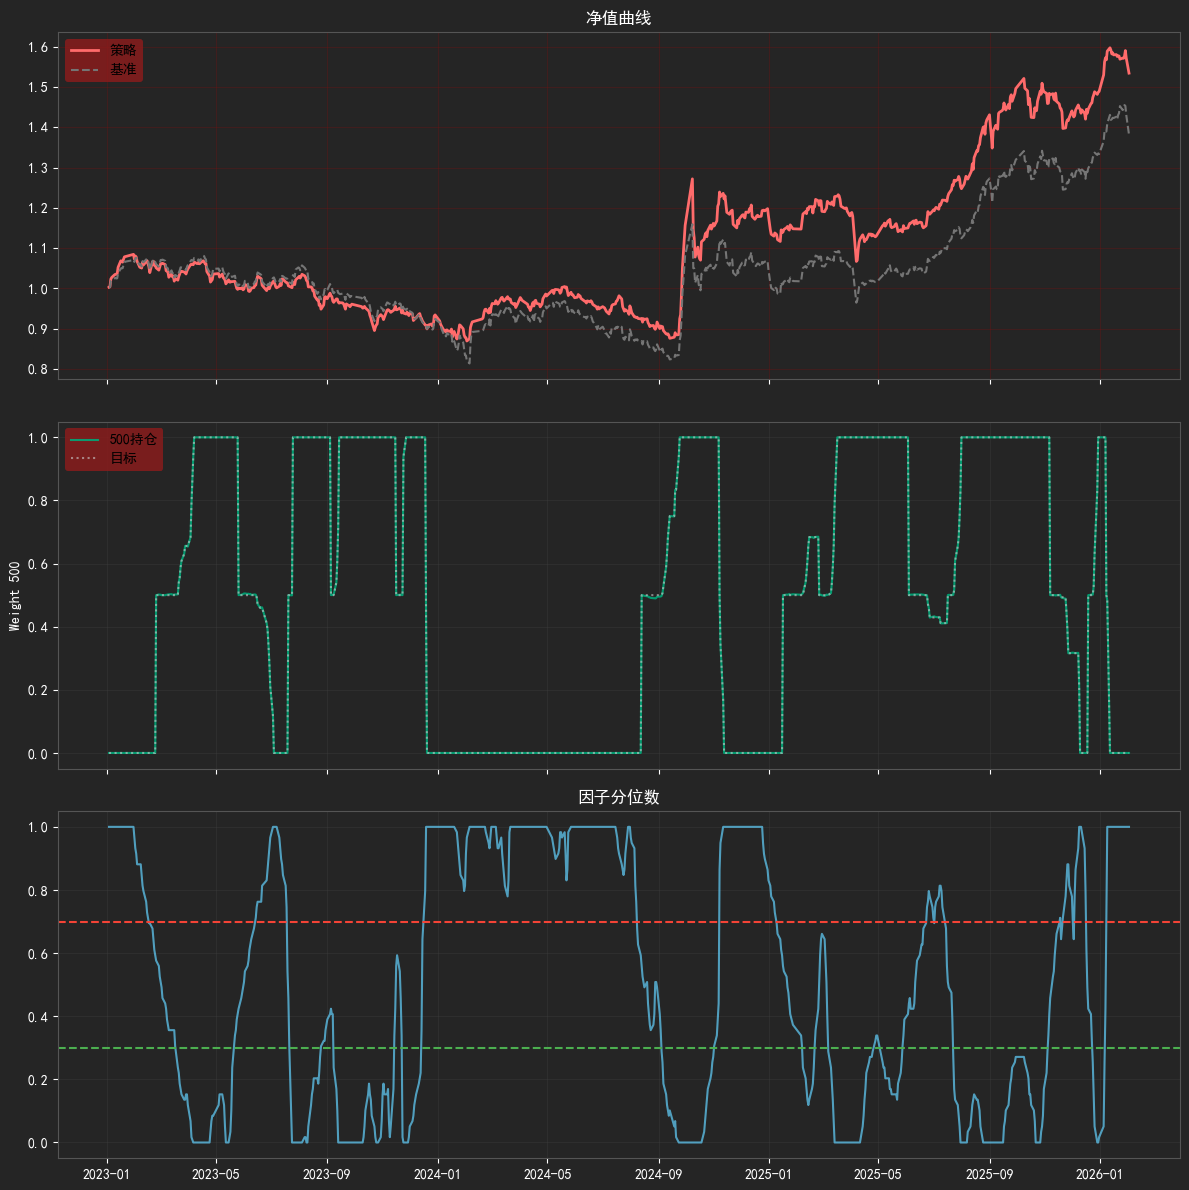

In [446]:
def analyze_performance(df_bt):
    days = len(df_bt)
    ann_ret = (df_bt['Strat_Cum'].iloc[-1] / df_bt['Strat_Cum'].iloc[0]) ** (252 / days) - 1
    bench_ann = (df_bt['Bench_Cum'].iloc[-1] / df_bt['Bench_Cum'].iloc[0]) ** (252 / days) - 1
    mdd = (df_bt['Strat_Cum'] / df_bt['Strat_Cum'].cummax() - 1).min()
    excess = ann_ret - bench_ann
    avg_turnover = df_bt['Turnover'].mean()

    print("\n" + "=" * 50)
    print(f"🏆 最终策略绩效报告 (G组参数)")
    print("=" * 50)
    print(f"策略年化: {ann_ret:.2%}")
    print(f"基准年化: {bench_ann:.2%}")
    print(f"超额收益: {excess:.2%}")
    print(f"最大回撤: {mdd:.2%}")
    print(f"日均换手: {avg_turnover:.2%}")
    print(f"Calmar  : {ann_ret / abs(mdd):.2f}")

    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

    # 设置全局背景颜色
    fig.patch.set_facecolor('#252525')
    for ax in axes:
        ax.set_facecolor('#252525')

    # 调整线条颜色和样式
    axes[0].plot(df_bt['Strat_Cum'], label='策略', color="#ff6b6b", lw=2)  # 更鲜艳的红色
    axes[0].plot(df_bt['Bench_Cum'], label='基准', color='#757575', ls='--')  # 暗灰色
    axes[0].set_title('净值曲线', color="white")
    axes[0].legend(facecolor="#8F1B1B", edgecolor='none')
    axes[0].grid(True, alpha=0.3, color="#801010")  # 更暗的网格颜色

    axes[1].plot(df_bt['W_Final'], color='#00a878', alpha=0.9, lw=1.5, label='500持仓')  # 鲜艳绿色
    axes[1].plot(df_bt['Target_Exec'], color='#cccccc', alpha=0.6, ls=':', label='目标')  # 浅灰色
    axes[1].set_ylabel('Weight 500', color="white")
    axes[1].legend(facecolor='#8F1B1B', edgecolor='none')
    axes[1].grid(True, alpha=0.3, color='#444444')

    axes[2].plot(df_bt['Factor_Rank'], color='#63d2ff', alpha=0.7, label='Rank')  # 鲜艳蓝色
    axes[2].axhline(LINEAR_HIGH, color='#f44336', ls='--')  # 红色虚线
    axes[2].axhline(LINEAR_LOW, color='#4caf50', ls='--')  # 绿色虚线
    axes[2].set_title('因子分位数', color="white")
    axes[2].grid(True, alpha=0.3, color='#444444')

     # === 统一设置所有子图的刻度、标签、边框样式 ===
    for ax in axes:
        # 刻度标签颜色
        ax.tick_params(
            axis='both',
            colors='white',          # 刻度标签文字颜色
            which='both'
        )
        # 坐标轴脊柱（边框）颜色
        for spine in ax.spines.values():
            spine.set_color('#555555')
        # 如果有 y 轴标签，也设为白色
        if ax.get_ylabel():
            ax.yaxis.label.set_color('white')

    # x 轴标签（共享）也设为白色
    axes[-1].tick_params(axis='x', colors='white')

    plt.tight_layout()
    plt.show()

    # 保存图表（可选）
    # output_path = os.path.join(OUTPUT_DIR, 'caprot_performance.png')
    # plt.savefig(output_path, dpi=300, bbox_inches='tight')
    # print(f"图表已保存到 {output_path}")

analyze_performance(df_bt)